使用デバイス: cuda | モデル: FC_Only_Annealing_ep100_beta50
Epoch [  1/100] | Total: 880.8729 (MSE: 880.8729, KLD: 1309.9176) | beta: 0.000
Epoch [  2/100] | Total: 91.3849 (MSE: 84.5379, KLD: 342.3457) | beta: 0.020
Epoch [  3/100] | Total: 61.6483 (MSE: 55.7516, KLD: 147.4180) | beta: 0.040
Epoch [  4/100] | Total: 50.6704 (MSE: 45.5162, KLD: 85.9033) | beta: 0.060
Epoch [  5/100] | Total: 47.4441 (MSE: 42.2298, KLD: 65.1789) | beta: 0.080
Epoch [  6/100] | Total: 45.9903 (MSE: 40.7587, KLD: 52.3158) | beta: 0.100
Epoch [  7/100] | Total: 46.9761 (MSE: 41.8207, KLD: 42.9613) | beta: 0.120
Epoch [  8/100] | Total: 50.0236 (MSE: 44.2970, KLD: 40.9040) | beta: 0.140
Epoch [  9/100] | Total: 48.3966 (MSE: 42.5054, KLD: 36.8200) | beta: 0.160
Epoch [ 10/100] | Total: 47.9921 (MSE: 42.0868, KLD: 32.8073) | beta: 0.180
Epoch [ 11/100] | Total: 49.0801 (MSE: 43.2418, KLD: 29.1915) | beta: 0.200
Epoch [ 12/100] | Total: 47.6952 (MSE: 42.3964, KLD: 24.0855) | beta: 0.220
Epoch [ 13/100] | Total: 46.335

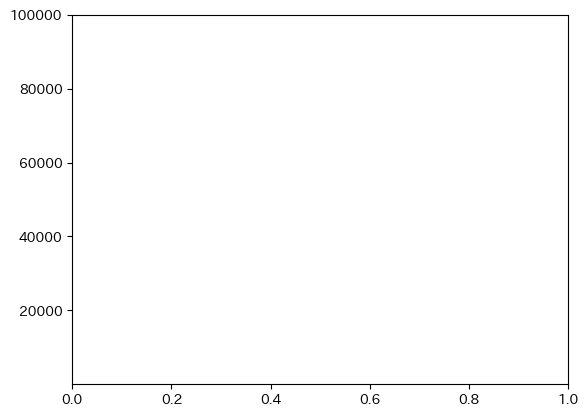

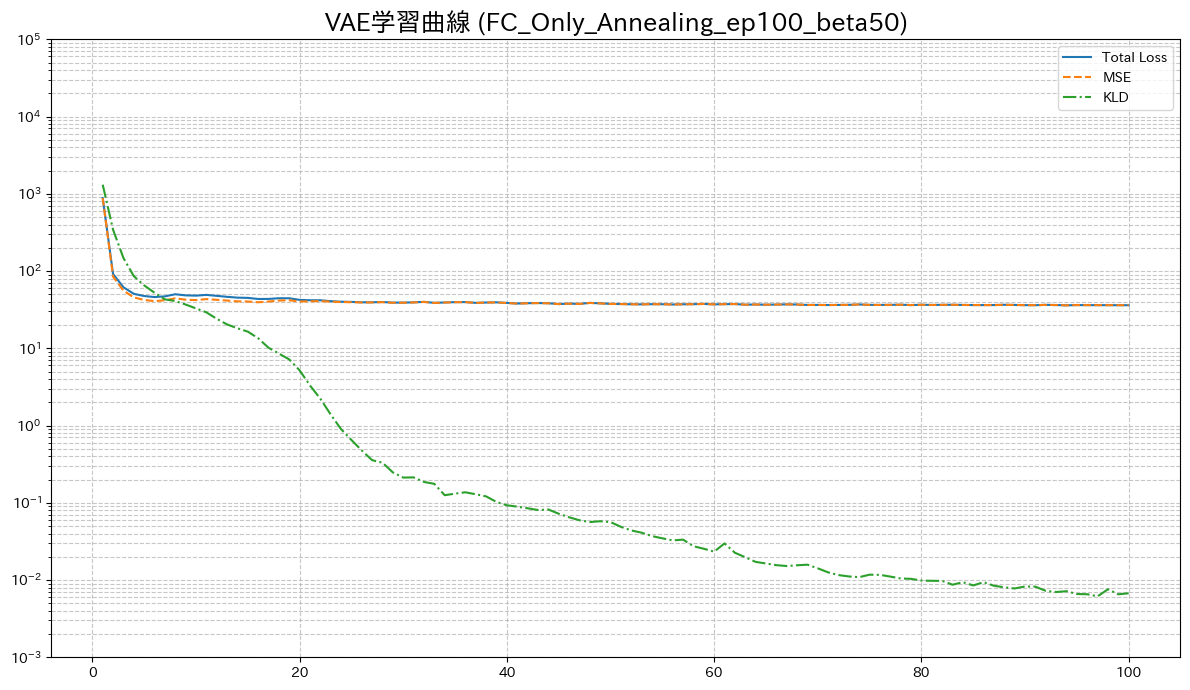

In [ ]:
# 1. 全結合層のみのモデル（FC_Only）100エポックバージョン
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import os

# 日本語フォント設定
try:
    import japanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'MS Gothic'
plt.ylim(1e-3, 1e5)
# =====================================================================
# 1. データセットと前処理
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = list(Path(root_dir).glob("train/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# =====================================================================
# 2. モデル定義: 全結合層のみ (FC_Only)
# =====================================================================
class VAE_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_FC, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(16384, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 16384), nn.Sigmoid()
        )

    def forward(self, x):
        h = torch.flatten(x, start_dim=1)
        h = self.encoder(h)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        recon = self.decoder(z)
        return recon.view(-1, 1, 128, 128), mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):  
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + beta * KLD

# =====================================================================
# 3. 学習ループ
# =====================================================================
if __name__ == "__main__":
    DATA_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle"
    SAVE_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models"
    MODEL_NAME = "FC_Only_Annealing_ep100_beta50"
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device} | モデル: {MODEL_NAME}")
    
    model = VAE_FC(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 100
    
    # ★ 設定: 何エポックかけて beta を 1.0 に到達させるか (ここでは50エポック)
    ANNEALING_EPOCHS = 50
    
    mse_history, kld_history, total_loss_history = [], [], []
    
    model.train()
    for epoch in range(epochs):
        # ★ 変更: 現在のエポック数に応じて beta (0.0 ～ 1.0) を計算
        beta = min(1.0, epoch / ANNEALING_EPOCHS)
        
        train_mse, train_kld, train_total = 0, 0, 0
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            # ★ 変更: 計算した beta を関数に渡す
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar, beta=beta)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataset)
        avg_kld = train_kld / len(dataset)
        avg_total = train_total / len(dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f}) | beta: {beta:.3f}")
            
    # 保存処理
    save_path = Path(SAVE_DIR)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_path / f"vae_{MODEL_NAME}_128.pth")
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(1, epochs + 1), total_loss_history, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, linestyle='--', label='MSE')
    plt.plot(range(1, epochs + 1), kld_history, linestyle='-.', label='KLD')
    plt.title(f'VAE学習曲線 ({MODEL_NAME})', fontsize=18, fontweight='bold')
    plt.yscale('log')
    plt.ylim(1e-3, 1e5)
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f"loss_curve_{MODEL_NAME}.png")
    plt.show()

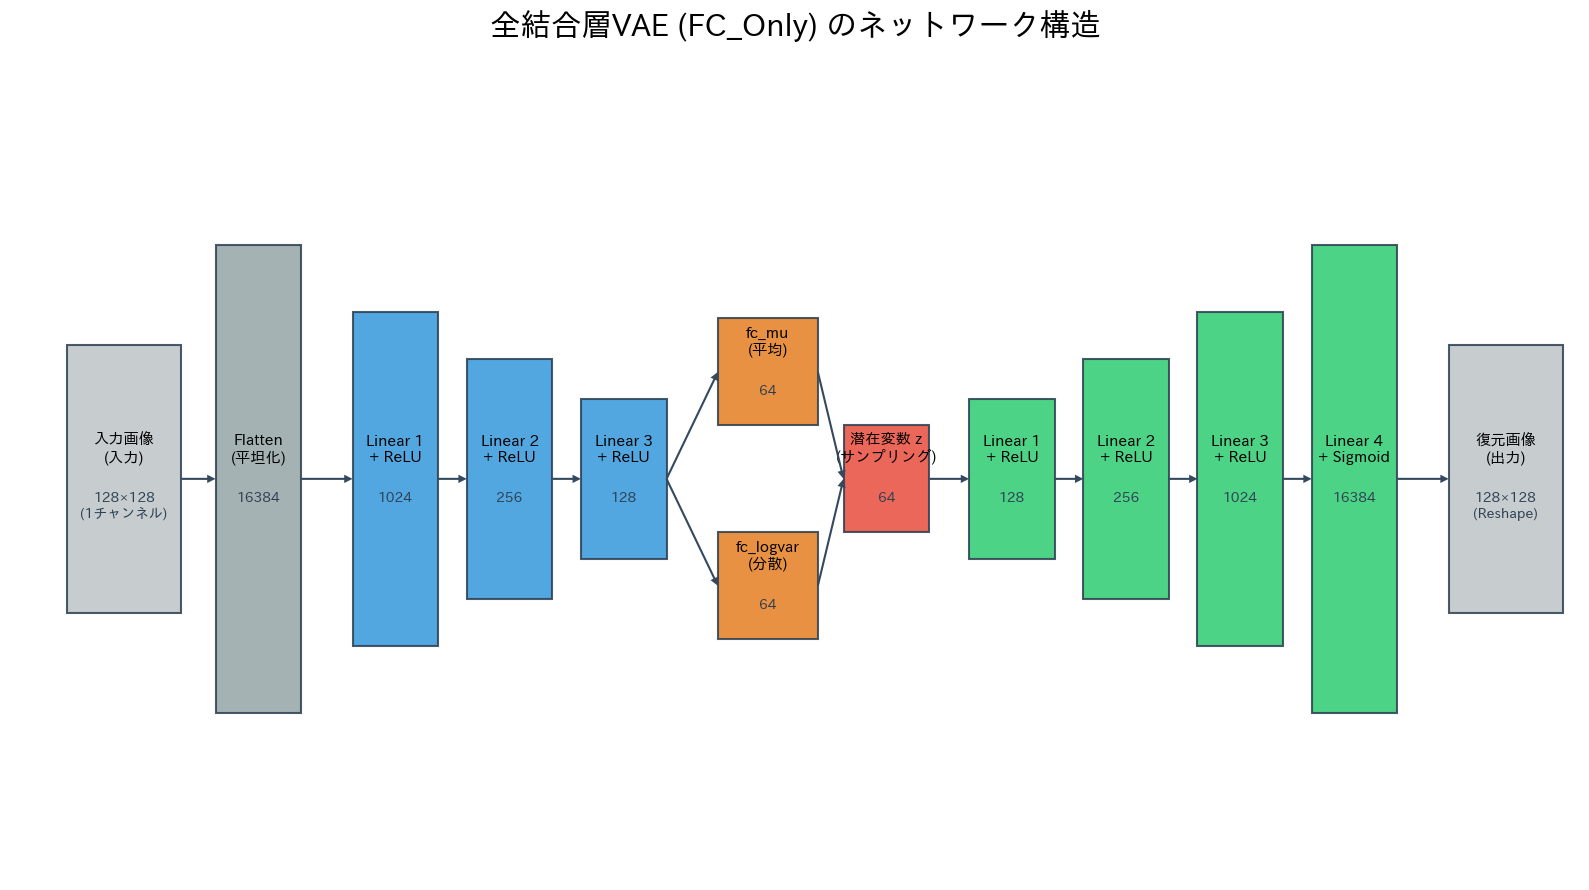

In [ ]:
# FC_Onlyの可視化
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ★ ここを修正: インポートした上で、強制的に設定を再適用させる
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 可視化用の設定
# =====================================================================
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
ax.axis('off')

plt.title("全結合層VAE (FC_Only) のネットワーク構造", fontsize=22, fontweight='bold', pad=30)

# 各層の定義 [x座標, y中央, 幅, 高さ, ラベル, 次元数/サイズ, 色]
layers = [
    # 入力
    [0.5, 3.0, 0.8, 2.0, "入力画像\n(入力)", "128×128\n(1チャンネル)", "#bdc3c7"],
    [1.8, 3.0, 0.6, 3.5, "Flatten\n(平坦化)", "16384", "#95a5a6"],
    
    # エンコーダ
    [3.0, 3.0, 0.6, 2.5, "Linear 1\n+ ReLU", "1024", "#3498db"],
    [4.0, 3.0, 0.6, 1.8, "Linear 2\n+ ReLU", "256", "#3498db"],
    [5.0, 3.0, 0.6, 1.2, "Linear 3\n+ ReLU", "128", "#3498db"],
    
    # 潜在空間 (上下に分岐)
    [6.2, 3.8, 0.7, 0.8, "fc_mu\n(平均)", "64", "#e67e22"],
    [6.2, 2.2, 0.7, 0.8, "fc_logvar\n(分散)", "64", "#e67e22"],
    [7.3, 3.0, 0.6, 0.8, "潜在変数 z\n(サンプリング)", "64", "#e74c3c"],
    
    # デコーダ
    [8.4, 3.0, 0.6, 1.2, "Linear 1\n+ ReLU", "128", "#2ecc71"],
    [9.4, 3.0, 0.6, 1.8, "Linear 2\n+ ReLU", "256", "#2ecc71"],
    [10.4, 3.0, 0.6, 2.5, "Linear 3\n+ ReLU", "1024", "#2ecc71"],
    [11.4, 3.0, 0.6, 3.5, "Linear 4\n+ Sigmoid", "16384", "#2ecc71"],
    
    # 出力
    [12.6, 3.0, 0.8, 2.0, "復元画像\n(出力)", "128×128\n(Reshape)", "#bdc3c7"]
]

# 横軸のスケールを合わせるために座標調整
x_scale = 0.8
for l in layers:
    x_mid, y_mid, w, h, label, info, color = l
    x = x_mid * x_scale
    y = y_mid - h/2
    
    # ブロックを描画
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='#2c3e50', facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    
    # テキスト（層の名前）
    ax.text(x + w/2, y_mid + 0.1, label, ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
    # テキスト（次元数）
    ax.text(x + w/2, y_mid - 0.1, info, ha='center', va='top', fontsize=10, color='#2c3e50', style='italic')

# ---------------------------------------------------
# 矢印（データの流れ）の描画
# ---------------------------------------------------
# shrink=0 にすることで、指定した座標の端から端までぴったり矢印を描画します
arrow_style = dict(facecolor='#34495e', edgecolor='none', width=1.5, headwidth=6, headlength=6, shrink=0)

# x_scaleの自動計算を外し、絶対座標で指定する関数に変更
def draw_arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_style)

# 各ボックスの「右端」から「左端」へ正確に繋ぐ
draw_arrow(1.20, 3.0, 1.44, 3.0)  # 入力画像 -> Flatten
draw_arrow(2.04, 3.0, 2.40, 3.0)  # Flatten -> Linear 1
draw_arrow(3.00, 3.0, 3.20, 3.0)  # Linear 1 -> Linear 2
draw_arrow(3.80, 3.0, 4.00, 3.0)  # Linear 2 -> Linear 3

# Linear 3 (右端 x=4.6) から分岐
draw_arrow(4.60, 3.0, 4.96, 3.8)  # Linear 3 -> fc_mu (左端 x=4.96)
draw_arrow(4.60, 3.0, 4.96, 2.2)  # Linear 3 -> fc_logvar (左端 x=4.96)

# 潜在変数 z (左端 x=5.84) へ合流
draw_arrow(5.66, 3.8, 5.84, 3.0)  # fc_mu (右端 x=5.66) -> z
draw_arrow(5.66, 2.2, 5.84, 3.0)  # fc_logvar (右端 x=5.66) -> z
oder_fc -> Reshape
draw_arrow(11.2, 3.0, 11.5, 3.0) # Reshape -> ConvTr 1
draw_arrow(12.2, 3.0, 12.5, 3.0) # ConvTr 1 -> ConvTr 2
draw_arrow(13.2, 3.0, 13.5, 3.0) # ConvTr 2 -> ConvTr 3
draw_arrow(14.2, 3.0, 14.5, 3.0) # ConvTr 3 -> ConvTr 4
draw_arrow(15.2, 3.0, 15.5, 3.0) # ConvTr 4 -> ConvTr 5
draw_arrow(16.2, 3.0, 16.5, 3.0) # Con
# z からデコーダ
draw_arrow(6.44, 3.0, 6.72, 3.0)  # z -> Linear 1
draw_arrow(7.32, 3.0, 7.52, 3.0)  # Linear 1 -> Linear 2
draw_arrow(8.12, 3.0, 8.32, 3.0)  # Linear 2 -> Linear 3
draw_arrow(8.92, 3.0, 9.12, 3.0)  # Linear 3 -> Linear 4
draw_arrow(9.72, 3.0, 10.08, 3.0) # Linear 4 -> 復元画像

# ---------------------------------------------------
# セクション全体の枠線とラベル
# ---------------------------------------------------
# Encoderの範囲
# ax.text(3.3, 0.4, "【 エンコーダ 部 】\n画像を潜在空間のパラメータへ圧縮", 
        # ha='center', fontsize=12, color='#2980b9', fontweight='bold', bbox=dict(facecolor='#ebf5fb', edgecolor='#3498db', boxstyle='round,pad=0.5'))
# Decoderの範囲
# ax.text(8.3, 0.4, "【 デコーダ 部 】\n潜在変数から元の画像を復元", 
#         ha='center', fontsize=12, color='#27ae60', fontweight='bold', bbox=dict(facecolor='#e8f8f5', edgecolor='#2ecc71', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

使用デバイス: cuda | モデル: CNN_Shallow3_Annealing_ep100_beta50
Epoch [  1/100] | Total: 1788.8856 (MSE: 1788.8856, KLD: 8599.1604) | beta: 0.000
Epoch [  2/100] | Total: 864.7447 (MSE: 740.2605, KLD: 6224.2117) | beta: 0.020
Epoch [  3/100] | Total: 430.6853 (MSE: 408.3698, KLD: 557.8868) | beta: 0.040
Epoch [  4/100] | Total: 291.6523 (MSE: 267.9456, KLD: 395.1118) | beta: 0.060
Epoch [  5/100] | Total: 223.8909 (MSE: 194.6375, KLD: 365.6670) | beta: 0.080
Epoch [  6/100] | Total: 181.8072 (MSE: 149.6012, KLD: 322.0601) | beta: 0.100
Epoch [  7/100] | Total: 155.9549 (MSE: 119.9584, KLD: 299.9713) | beta: 0.120
Epoch [  8/100] | Total: 141.7103 (MSE: 100.0440, KLD: 297.6161) | beta: 0.140
Epoch [  9/100] | Total: 137.0484 (MSE: 89.0496, KLD: 299.9926) | beta: 0.160
Epoch [ 10/100] | Total: 139.5540 (MSE: 80.6064, KLD: 327.4863) | beta: 0.180
Epoch [ 11/100] | Total: 151.5715 (MSE: 75.1566, KLD: 382.0749) | beta: 0.200
Epoch [ 12/100] | Total: 199.7375 (MSE: 77.8224, KLD: 554.1595) | beta: 0.

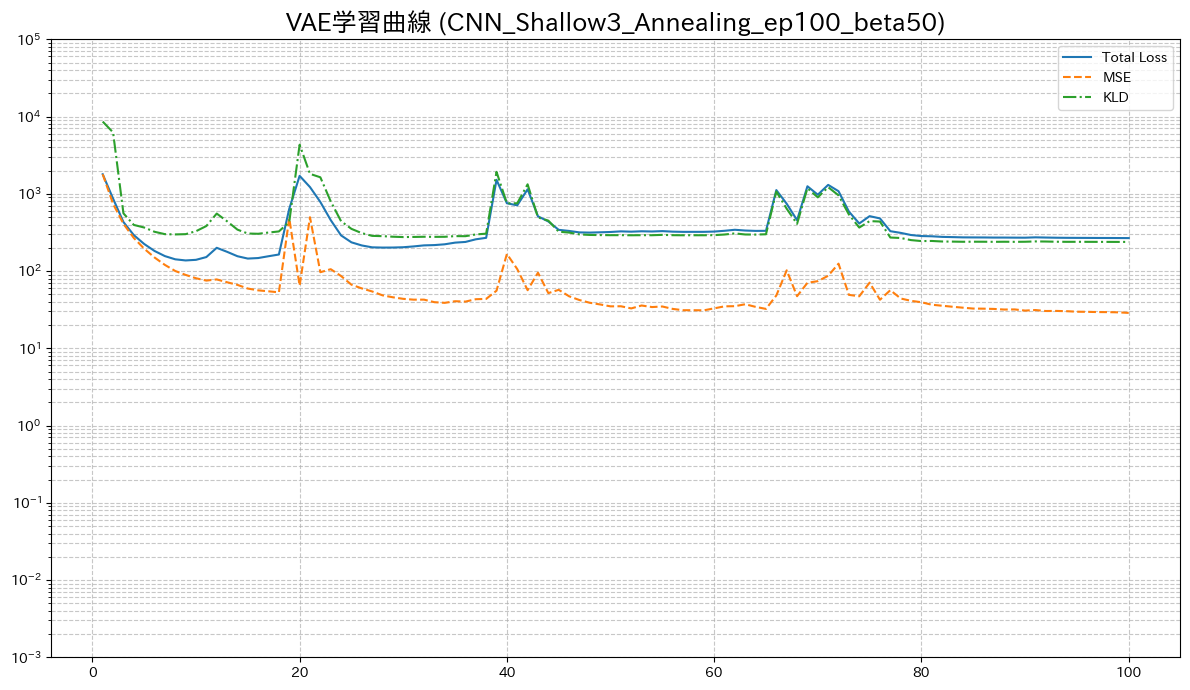

In [2]:
# 2. 浅いCNNモデル（CNN_Shallow3）
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import os

# 日本語フォント設定
try:
    import japanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'MS Gothic'

# =====================================================================
# 1. データセットと前処理
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = list(Path(root_dir).glob("train/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# =====================================================================
# 2. モデル定義: 浅いCNNモデル (CNN_Shallow3)
# =====================================================================
class VAE_CNN_Shallow3(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Shallow3, self).__init__()
        
        # エンコーダ: 畳み込み層で空間情報を保ちながら圧縮 (128 -> 64 -> 32 -> 16)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # ★ 紛れ込んでいた plt.ylim をここから削除しました！
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # 64チャンネル * 16 * 16 = 16384次元
        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(64 * 16 * 16, latent_dim)
        
        self.decoder_fc = nn.Linear(latent_dim, 64 * 16 * 16)
        
        # デコーダ: 逆畳み込み層で元の画像サイズへ復元
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 64, 16, 16) # 4階テンソルに戻す
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):  
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + beta * KLD

# =====================================================================
# 3. 学習ループ
# =====================================================================
if __name__ == "__main__":
    # ★重要: OSに依存しない相対パスに変更 (エラー回避)
    DATA_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle"
    SAVE_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models"
    MODEL_NAME = "CNN_Shallow3_Annealing_ep100_beta50"
    
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device} | モデル: {MODEL_NAME}")
    
    model = VAE_CNN_Shallow3(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 100
    ANNEALING_EPOCHS = 50
    
    mse_history, kld_history, total_loss_history = [], [], []
    
    model.train()
    for epoch in range(epochs):
        beta = min(1.0, epoch / ANNEALING_EPOCHS)
        
        train_mse, train_kld, train_total = 0, 0, 0
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar, beta=beta)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataset)
        avg_kld = train_kld / len(dataset)
        avg_total = train_total / len(dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f}) | beta: {beta:.3f}")
            
    # 保存処理
    save_path = Path(SAVE_DIR)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_path / f"vae_{MODEL_NAME}_128.pth")
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(1, epochs + 1), total_loss_history, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, linestyle='--', label='MSE')
    plt.plot(range(1, epochs + 1), kld_history, linestyle='-.', label='KLD')
    plt.title(f'VAE学習曲線 ({MODEL_NAME})', fontsize=18, fontweight='bold')
    plt.yscale('log')
    plt.ylim(1e-3, 1e5) 
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f"loss_curve_{MODEL_NAME}.png")
    plt.show()

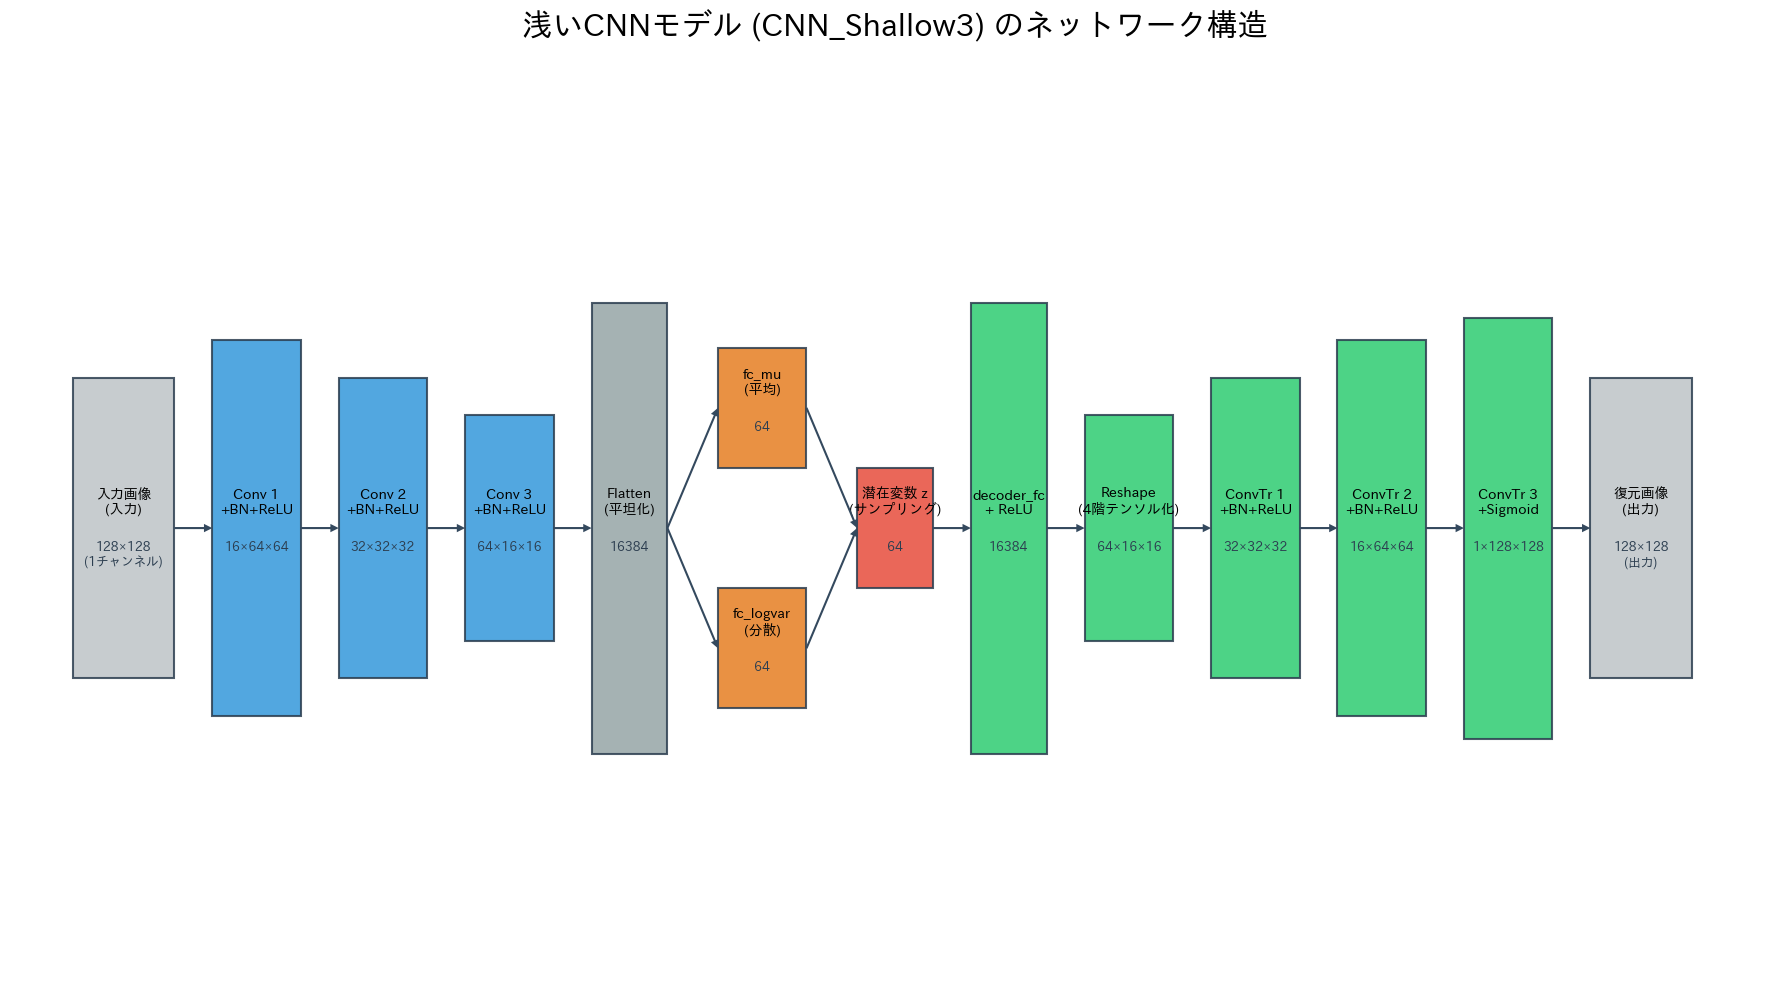

In [3]:
# CNN_Shallow3の可視化
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 仮想環境にインストールしたjapanize_matplotlibを読み込み、強制適用（文字化け対策）
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 可視化用の設定
# =====================================================================
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

plt.title("浅いCNNモデル (CNN_Shallow3) のネットワーク構造", fontsize=22, fontweight='bold', pad=30)

# 各層の定義 [x左端, y中央, 幅, 高さ, ラベル, 次元数/サイズ, 色]
layers = [
    # 入力
    [0.5, 3.0, 0.8, 2.0, "入力画像\n(入力)", "128×128\n(1チャンネル)", "#bdc3c7"],
    
    # エンコーダ（畳み込み層）
    [1.6, 3.0, 0.7, 2.5, "Conv 1\n+BN+ReLU", "16×64×64", "#3498db"],
    [2.6, 3.0, 0.7, 2.0, "Conv 2\n+BN+ReLU", "32×32×32", "#3498db"],
    [3.6, 3.0, 0.7, 1.5, "Conv 3\n+BN+ReLU", "64×16×16", "#3498db"],
    [4.6, 3.0, 0.6, 3.0, "Flatten\n(平坦化)", "16384", "#95a5a6"],
    
    # 潜在空間 (上下に分岐)
    [5.6, 3.8, 0.7, 0.8, "fc_mu\n(平均)", "64", "#e67e22"],
    [5.6, 2.2, 0.7, 0.8, "fc_logvar\n(分散)", "64", "#e67e22"],
    [6.7, 3.0, 0.6, 0.8, "潜在変数 z\n(サンプリング)", "64", "#e74c3c"],
    
    # デコーダ（逆畳み込み層へ向かう処理）
    [7.6, 3.0, 0.6, 3.0, "decoder_fc\n+ ReLU", "16384", "#2ecc71"],
    [8.5, 3.0, 0.7, 1.5, "Reshape\n(4階テンソル化)", "64×16×16", "#2ecc71"],
    
    # デコーダ（逆畳み込み層）
    [9.5, 3.0, 0.7, 2.0, "ConvTr 1\n+BN+ReLU", "32×32×32", "#2ecc71"],
    [10.5, 3.0, 0.7, 2.5, "ConvTr 2\n+BN+ReLU", "16×64×64", "#2ecc71"],
    [11.5, 3.0, 0.7, 2.8, "ConvTr 3\n+Sigmoid", "1×128×128", "#2ecc71"],
    
    # 出力
    [12.5, 3.0, 0.8, 2.0, "復元画像\n(出力)", "128×128\n(出力)", "#bdc3c7"]
]

for l in layers:
    x, y_mid, w, h, label, info, color = l
    y = y_mid - h/2
    
    # ブロックを描画
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='#2c3e50', facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    
    # テキスト（層の名前）
    ax.text(x + w/2, y_mid + 0.08, label, ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')
    # テキスト（次元数や画像サイズ）
    ax.text(x + w/2, y_mid - 0.08, info, ha='center', va='top', fontsize=9, color='#2c3e50', style='italic')

# ---------------------------------------------------
# 矢印（データの流れ）の描画
# ---------------------------------------------------
arrow_style = dict(facecolor='#34495e', edgecolor='none', width=1.5, headwidth=6, headlength=6, shrink=0)

def draw_arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_style)

# 入力からエンコーダ（畳み込み層）
draw_arrow(1.3, 3.0, 1.6, 3.0)  # 入力画像 -> Conv 1
draw_arrow(2.3, 3.0, 2.6, 3.0)  # Conv 1 -> Conv 2
draw_arrow(3.3, 3.0, 3.6, 3.0)  # Conv 2 -> Conv 3
draw_arrow(4.3, 3.0, 4.6, 3.0)  # Conv 3 -> Flatten

# Flattenから潜在変数への分岐
draw_arrow(5.2, 3.0, 5.6, 3.8)  # Flatten -> fc_mu
draw_arrow(5.2, 3.0, 5.6, 2.2)  # Flatten -> fc_logvar

# 潜在変数から z への合流
draw_arrow(6.3, 3.8, 6.7, 3.0)  # fc_mu -> z
draw_arrow(6.3, 2.2, 6.7, 3.0)  # fc_logvar -> z

# z からデコーダ
draw_arrow(7.3, 3.0, 7.6, 3.0)  # z -> decoder_fc
draw_arrow(8.2, 3.0, 8.5, 3.0)  # decoder_fc -> Reshape
draw_arrow(9.2, 3.0, 9.5, 3.0)  # Reshape -> ConvTr 1
draw_arrow(10.2, 3.0, 10.5, 3.0) # ConvTr 1 -> ConvTr 2
draw_arrow(11.2, 3.0, 11.5, 3.0) # ConvTr 2 -> ConvTr 3
draw_arrow(12.2, 3.0, 12.5, 3.0) # ConvTr 3 -> 復元画像

# ---------------------------------------------------
# セクション全体の枠線とラベル
# ---------------------------------------------------
# Encoderの範囲
# ax.text(2.9, 0.4, "【 エンコーダ 部 】\n畳み込み層(Conv2d)で空間的な特徴を保持しながら圧縮", 
#         ha='center', fontsize=11, color='#2980b9', fontweight='bold', bbox=dict(facecolor='#ebf5fb', edgecolor='#3498db', boxstyle='round,pad=0.5'))
# # Decoderの範囲
# ax.text(10.2, 0.4, "【 デコーダ 部 】\n逆畳み込み層(ConvTranspose2d)で画像サイズを拡大・復元", 
#         ha='center', fontsize=11, color='#27ae60', fontweight='bold', bbox=dict(facecolor='#e8f8f5', edgecolor='#2ecc71', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

使用デバイス: cuda | モデル: CNN_Deep5_Annealing_ep100_beta50
Epoch [  1/100] | Total: 1880.2070 (MSE: 1880.2070, KLD: 609.9300) | beta: 0.000
Epoch [  2/100] | Total: 815.0588 (MSE: 794.4261, KLD: 1031.6339) | beta: 0.020
Epoch [  3/100] | Total: 469.8237 (MSE: 461.6709, KLD: 203.8218) | beta: 0.040
Epoch [  4/100] | Total: 329.4672 (MSE: 319.9525, KLD: 158.5789) | beta: 0.060
Epoch [  5/100] | Total: 246.2323 (MSE: 236.1290, KLD: 126.2906) | beta: 0.080
Epoch [  6/100] | Total: 189.7633 (MSE: 180.0029, KLD: 97.6036) | beta: 0.100
Epoch [  7/100] | Total: 149.9971 (MSE: 141.3297, KLD: 72.2281) | beta: 0.120
Epoch [  8/100] | Total: 124.7828 (MSE: 115.0095, KLD: 69.8089) | beta: 0.140
Epoch [  9/100] | Total: 107.6871 (MSE: 97.1623, KLD: 65.7800) | beta: 0.160
Epoch [ 10/100] | Total: 94.4945 (MSE: 84.9178, KLD: 53.2039) | beta: 0.180
Epoch [ 11/100] | Total: 88.8384 (MSE: 76.5150, KLD: 61.6169) | beta: 0.200
Epoch [ 12/100] | Total: 82.3080 (MSE: 70.5556, KLD: 53.4200) | beta: 0.220
Epoch [ 13

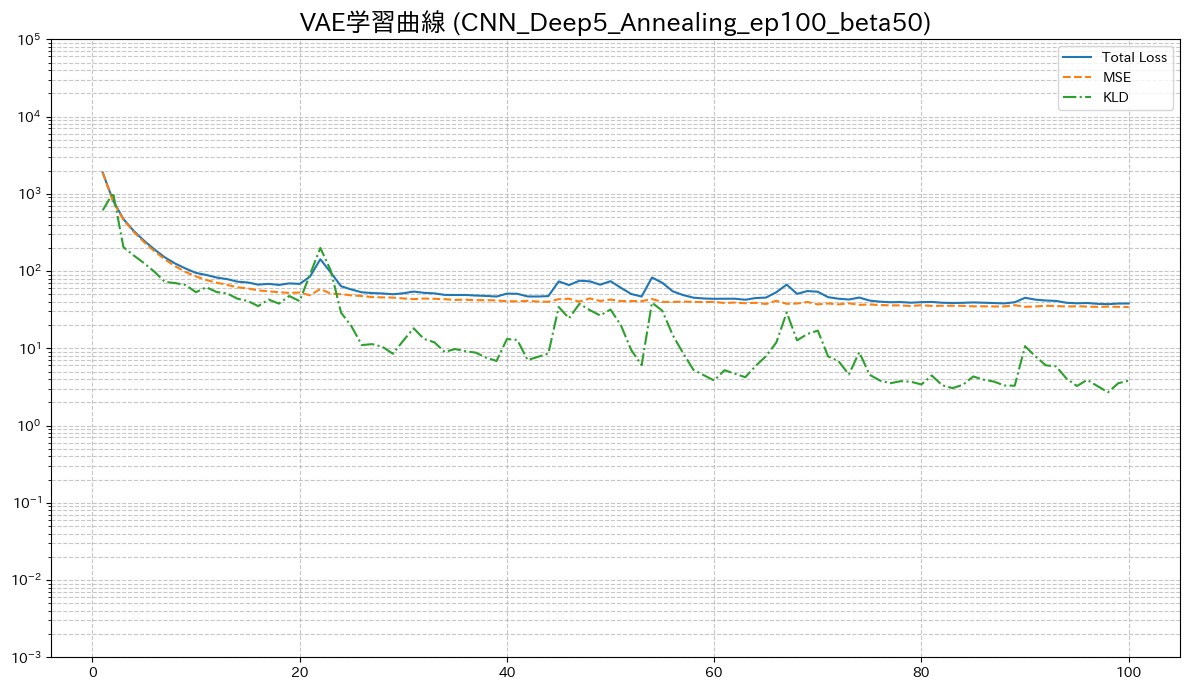

In [4]:
# 3. 深いCNNモデル（CNN_Deep5）
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import os

# 日本語フォント設定
try:
    import japanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'MS Gothic'

# =====================================================================
# 1. データセットと前処理
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = list(Path(root_dir).glob("train/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# =====================================================================
# 2. モデル定義: 深いCNNモデル (CNN_Deep5)
# =====================================================================
class VAE_CNN_Deep5(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Deep5, self).__init__()
        
        # エンコーダ: 畳み込み層を5層重ねてさらに深く圧縮 (128 -> 64 -> 32 -> 16 -> 8 -> 4)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # --- ここから追加した深い層 ---
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # 最終層のサイズ: 256チャンネル * 4ピクセル * 4ピクセル = 4096次元
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # デコーダ用の全結合層
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)
        
        # デコーダ: 逆畳み込み層を5層重ねて画像サイズを復元 (4 -> 8 -> 16 -> 32 -> 64 -> 128)
        self.decoder_conv = nn.Sequential(
            # --- ここから追加した深い層 ---
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # ------------------------------

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # ★重要: GPUでのKLD爆発を防ぐ安全装置
        logvar = torch.clamp(logvar, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) # 4階テンソルに戻す（256ch, 4x4）
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):  
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + beta * KLD

# =====================================================================
# 3. 学習ループ
# =====================================================================
if __name__ == "__main__":
    DATA_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle"
    SAVE_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models"
    MODEL_NAME = "CNN_Deep5_Annealing_ep100_beta50"
    
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device} | モデル: {MODEL_NAME}")
    
    model = VAE_CNN_Deep5(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 100
    ANNEALING_EPOCHS = 50
    
    mse_history, kld_history, total_loss_history = [], [], []
    
    model.train()
    for epoch in range(epochs):
        beta = min(1.0, epoch / ANNEALING_EPOCHS)
        
        train_mse, train_kld, train_total = 0, 0, 0
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar, beta=beta)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataset)
        avg_kld = train_kld / len(dataset)
        avg_total = train_total / len(dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f}) | beta: {beta:.3f}")
            
    # 保存処理
    save_path = Path(SAVE_DIR)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_path / f"vae_{MODEL_NAME}_128.pth")
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(1, epochs + 1), total_loss_history, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, linestyle='--', label='MSE')
    plt.plot(range(1, epochs + 1), kld_history, linestyle='-.', label='KLD')
    plt.title(f'VAE学習曲線 ({MODEL_NAME})', fontsize=18, fontweight='bold')
    plt.yscale('log')
    plt.ylim(1e-3, 1e5)
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f"loss_curve_{MODEL_NAME}.png")
    plt.show()

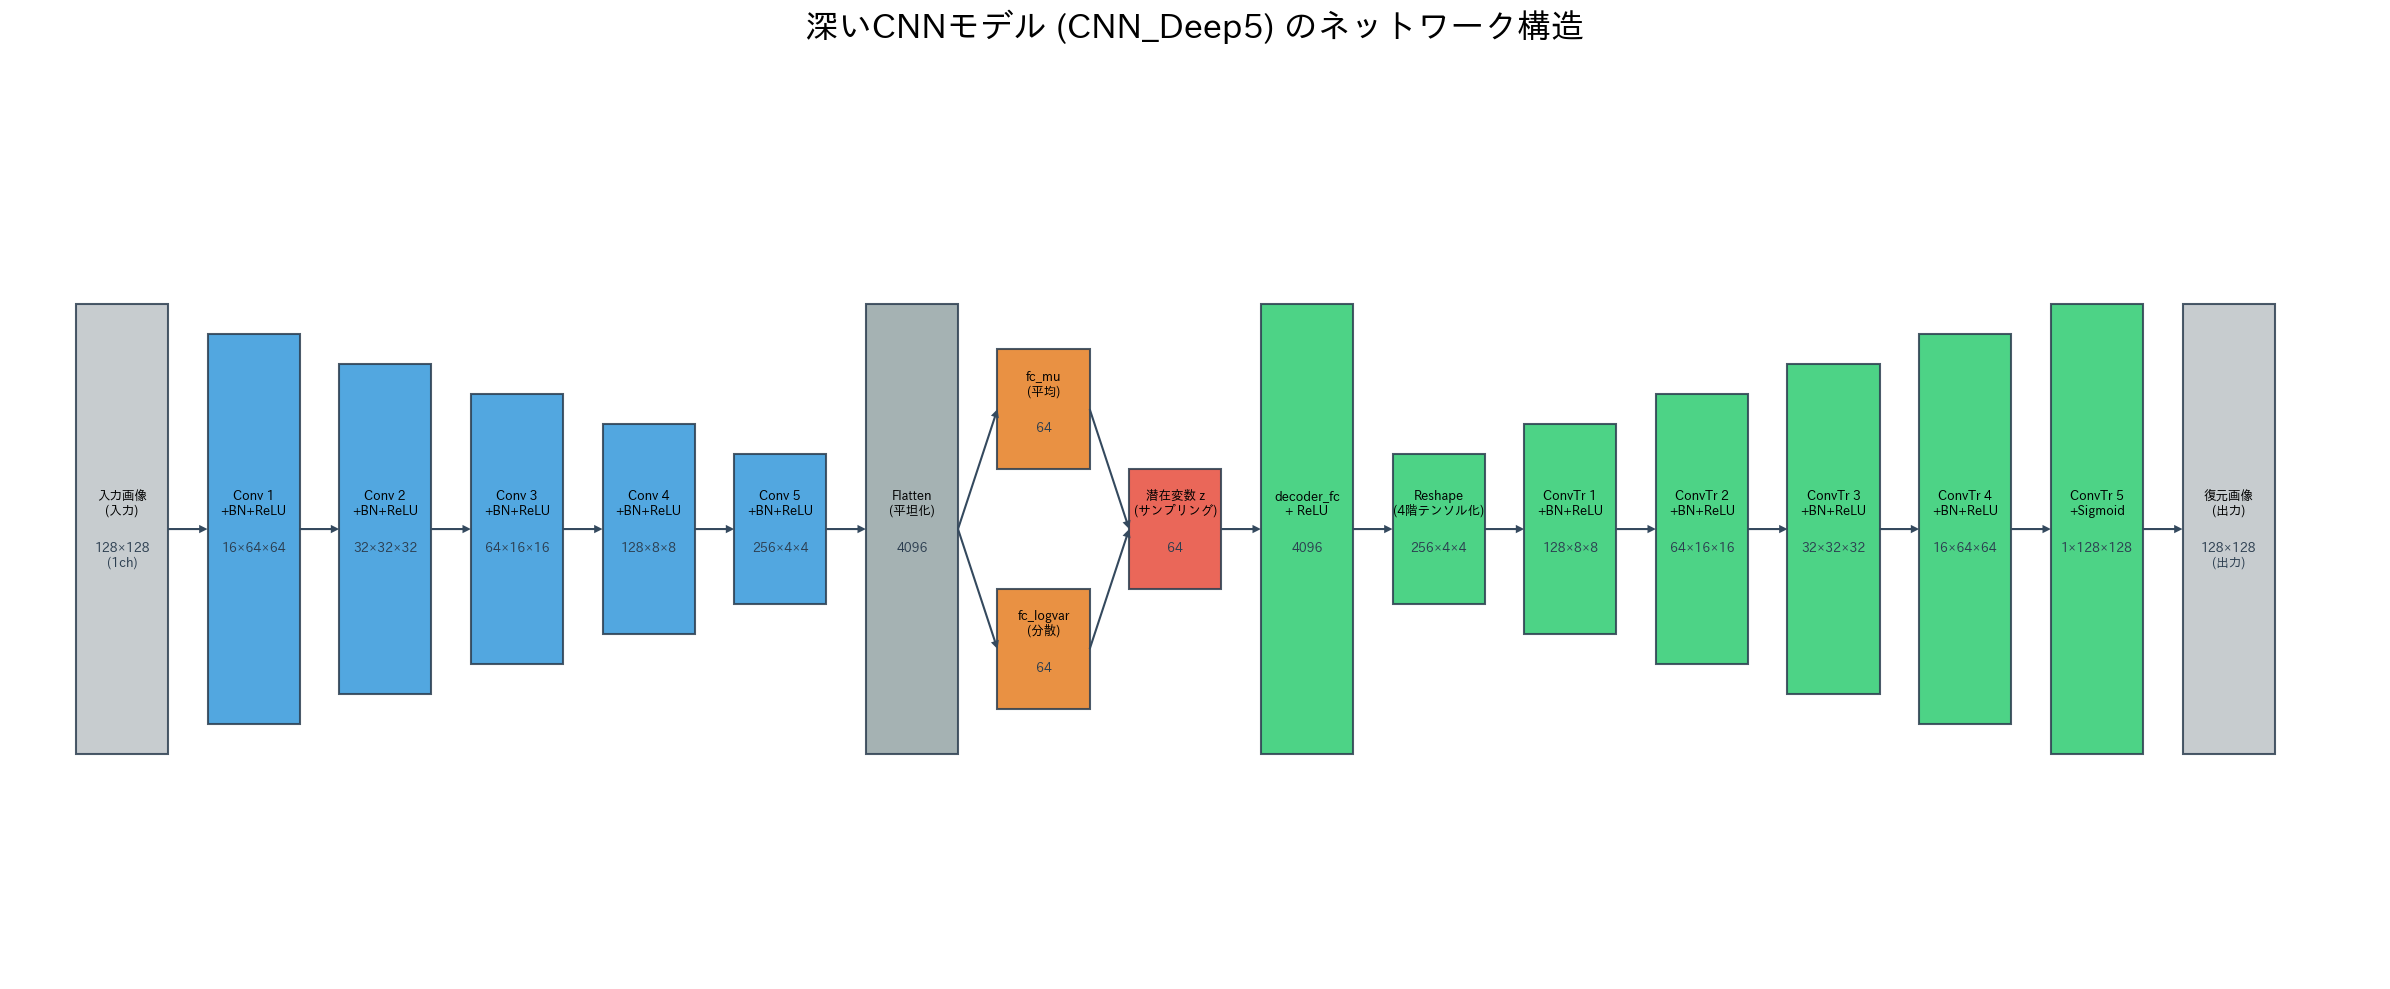

In [5]:
# CNN_Deep5の可視化
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import japanize_matplotlib

# 文字化け対策の強制適用
japanize_matplotlib.japanize()

# =====================================================================
# 可視化用の設定
# =====================================================================
# 層が増えたため横長に設定
fig, ax = plt.subplots(figsize=(24, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 6)
ax.axis('off')

plt.title("深いCNNモデル (CNN_Deep5) のネットワーク構造", fontsize=24, fontweight='bold', pad=30)

# 各層の定義 [x左端, y中央, 幅, 高さ, ラベル, 次元数/サイズ, 色]
layers = [
    # 入力
    [0.5, 3.0, 0.7, 3.0, "入力画像\n(入力)", "128×128\n(1ch)", "#bdc3c7"],
    
    # エンコーダ（畳み込み層）徐々に小さく
    [1.5, 3.0, 0.7, 2.6, "Conv 1\n+BN+ReLU", "16×64×64", "#3498db"],
    [2.5, 3.0, 0.7, 2.2, "Conv 2\n+BN+ReLU", "32×32×32", "#3498db"],
    [3.5, 3.0, 0.7, 1.8, "Conv 3\n+BN+ReLU", "64×16×16", "#3498db"],
    [4.5, 3.0, 0.7, 1.4, "Conv 4\n+BN+ReLU", "128×8×8", "#3498db"],
    [5.5, 3.0, 0.7, 1.0, "Conv 5\n+BN+ReLU", "256×4×4", "#3498db"],
    [6.5, 3.0, 0.7, 3.0, "Flatten\n(平坦化)", "4096", "#95a5a6"],
    
    # 潜在空間 (上下に分岐)
    [7.5, 3.8, 0.7, 0.8, "fc_mu\n(平均)", "64", "#e67e22"],
    [7.5, 2.2, 0.7, 0.8, "fc_logvar\n(分散)", "64", "#e67e22"],
    [8.5, 3.0, 0.7, 0.8, "潜在変数 z\n(サンプリング)", "64", "#e74c3c"],
    
    # デコーダ（逆畳み込み層へ向かう処理）
    [9.5, 3.0, 0.7, 3.0, "decoder_fc\n+ ReLU", "4096", "#2ecc71"],
    [10.5, 3.0, 0.7, 1.0, "Reshape\n(4階テンソル化)", "256×4×4", "#2ecc71"],
    
    # デコーダ（逆畳み込み層）徐々に大きく
    [11.5, 3.0, 0.7, 1.4, "ConvTr 1\n+BN+ReLU", "128×8×8", "#2ecc71"],
    [12.5, 3.0, 0.7, 1.8, "ConvTr 2\n+BN+ReLU", "64×16×16", "#2ecc71"],
    [13.5, 3.0, 0.7, 2.2, "ConvTr 3\n+BN+ReLU", "32×32×32", "#2ecc71"],
    [14.5, 3.0, 0.7, 2.6, "ConvTr 4\n+BN+ReLU", "16×64×64", "#2ecc71"],
    [15.5, 3.0, 0.7, 3.0, "ConvTr 5\n+Sigmoid", "1×128×128", "#2ecc71"],
    
    # 出力
    [16.5, 3.0, 0.7, 3.0, "復元画像\n(出力)", "128×128\n(出力)", "#bdc3c7"]
]

for l in layers:
    x, y_mid, w, h, label, info, color = l
    y = y_mid - h/2
    
    # ブロックを描画
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='#2c3e50', facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    
    # テキスト（層の名前）
    ax.text(x + w/2, y_mid + 0.08, label, ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    # テキスト（次元数や画像サイズ）
    ax.text(x + w/2, y_mid - 0.08, info, ha='center', va='top', fontsize=9, color='#2c3e50', style='italic')

# ---------------------------------------------------
# 矢印（データの流れ）の描画
# ---------------------------------------------------
arrow_style = dict(facecolor='#34495e', edgecolor='none', width=1.5, headwidth=6, headlength=6, shrink=0)

def draw_arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_style)

# 入力からエンコーダ（畳み込み層）
draw_arrow(1.2, 3.0, 1.5, 3.0)  # 入力画像 -> Conv 1
draw_arrow(2.2, 3.0, 2.5, 3.0)  # Conv 1 -> Conv 2
draw_arrow(3.2, 3.0, 3.5, 3.0)  # Conv 2 -> Conv 3
draw_arrow(4.2, 3.0, 4.5, 3.0)  # Conv 3 -> Conv 4
draw_arrow(5.2, 3.0, 5.5, 3.0)  # Conv 4 -> Conv 5
draw_arrow(6.2, 3.0, 6.5, 3.0)  # Conv 5 -> Flatten

# Flattenから潜在変数への分岐
draw_arrow(7.2, 3.0, 7.5, 3.8)  # Flatten -> fc_mu
draw_arrow(7.2, 3.0, 7.5, 2.2)  # Flatten -> fc_logvar

# 潜在変数から z への合流
draw_arrow(8.2, 3.8, 8.5, 3.0)  # fc_mu -> z
draw_arrow(8.2, 2.2, 8.5, 3.0)  # fc_logvar -> z

# z からデコーダ
draw_arrow(9.2, 3.0, 9.5, 3.0)   # z -> decoder_fc
draw_arrow(10.2, 3.0, 10.5, 3.0) # decoder_fc -> Reshape
draw_arrow(11.2, 3.0, 11.5, 3.0) # Reshape -> ConvTr 1
draw_arrow(12.2, 3.0, 12.5, 3.0) # ConvTr 1 -> ConvTr 2
draw_arrow(13.2, 3.0, 13.5, 3.0) # ConvTr 2 -> ConvTr 3
draw_arrow(14.2, 3.0, 14.5, 3.0) # ConvTr 3 -> ConvTr 4
draw_arrow(15.2, 3.0, 15.5, 3.0) # ConvTr 4 -> ConvTr 5
draw_arrow(16.2, 3.0, 16.5, 3.0) # ConvTr 5 -> 復元画像

# ---------------------------------------------------
# セクション全体の枠線とラベル
# ---------------------------------------------------
# Encoderの範囲
# ax.text(4.0, 0.4, "【 エンコーダ 部 】\n5層の畳み込みにより空間特徴を4×4まで極限圧縮", 
#         ha='center', fontsize=12, color='#2980b9', fontweight='bold', bbox=dict(facecolor='#ebf5fb', edgecolor='#3498db', boxstyle='round,pad=0.5'))
# # Decoderの範囲
# ax.text(13.0, 0.4, "【 デコーダ 部 】\n5層の逆畳み込みにより微細な構造から画像全体を復元", 
#         ha='center', fontsize=12, color='#27ae60', fontweight='bold', bbox=dict(facecolor='#e8f8f5', edgecolor='#2ecc71', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

使用デバイス: cuda | モデル: Hybrid_CNN5_FC_Annealing_ep100_beta50
Epoch [  1/100] | Total: 1516.1164 (MSE: 1516.1164, KLD: 13.3596) | beta: 0.000
Epoch [  2/100] | Total: 1112.5885 (MSE: 1109.2275, KLD: 168.0518) | beta: 0.020
Epoch [  3/100] | Total: 894.8537 (MSE: 888.5016, KLD: 158.8023) | beta: 0.040
Epoch [  4/100] | Total: 685.9941 (MSE: 680.2692, KLD: 95.4154) | beta: 0.060
Epoch [  5/100] | Total: 500.8592 (MSE: 495.4897, KLD: 67.1179) | beta: 0.080
Epoch [  6/100] | Total: 366.7351 (MSE: 362.0669, KLD: 46.6815) | beta: 0.100
Epoch [  7/100] | Total: 277.8265 (MSE: 272.0409, KLD: 48.2130) | beta: 0.120
Epoch [  8/100] | Total: 217.1364 (MSE: 212.4659, KLD: 33.3605) | beta: 0.140
Epoch [  9/100] | Total: 176.4647 (MSE: 171.9063, KLD: 28.4903) | beta: 0.160
Epoch [ 10/100] | Total: 147.4421 (MSE: 143.9956, KLD: 19.1471) | beta: 0.180
Epoch [ 11/100] | Total: 127.0364 (MSE: 124.2186, KLD: 14.0886) | beta: 0.200
Epoch [ 12/100] | Total: 111.3235 (MSE: 109.1472, KLD: 9.8924) | beta: 0.220
E

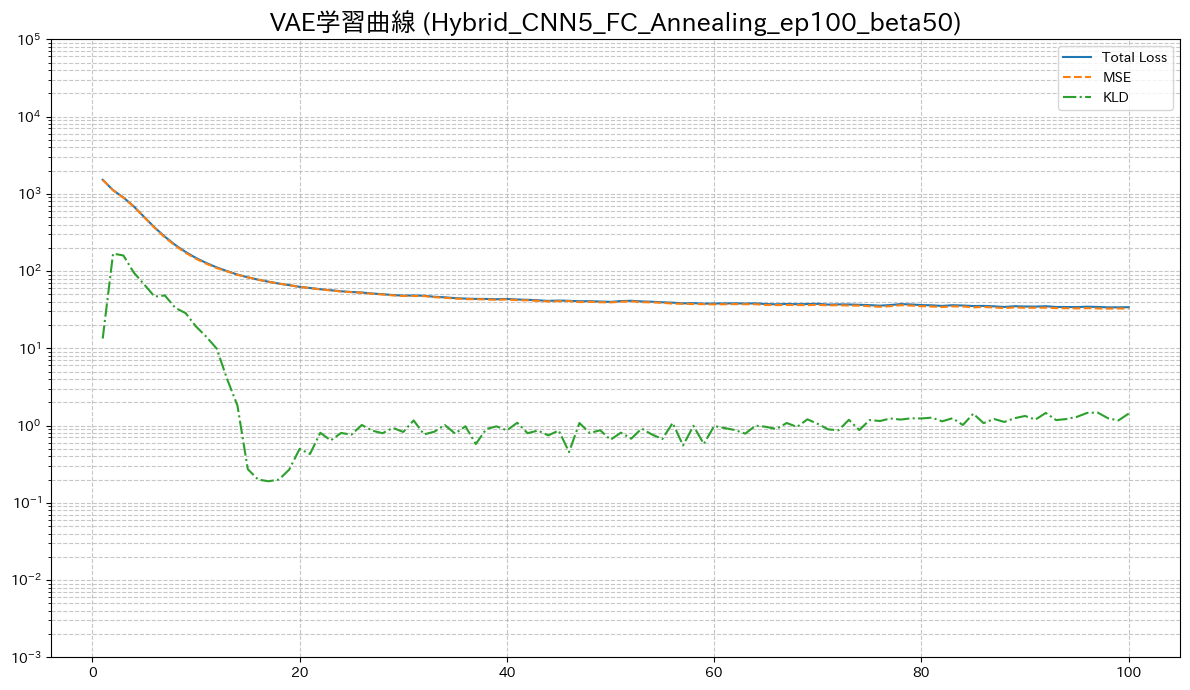

In [6]:
# 4. ハイブリッドモデル（CNN_Deep5 + FC_Only）
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import os

# 日本語フォント設定（文字化け対策込み）
try:
    import japanize_matplotlib
    japanize_matplotlib.japanize()
except ImportError:
    plt.rcParams['font.family'] = 'MS Gothic'

# =====================================================================
# 1. データセットと前処理
# =====================================================================
class MVTecTrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = list(Path(root_dir).glob("train/good/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

# =====================================================================
# 2. モデル定義: ハイブリッドモデル (CNN_Deep5 + FC_Only)
# =====================================================================
class VAE_Hybrid_CNN_FC(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        # -------------------------------------------------------------
        # 【エンコーダ前半】 CNN_Deep5（空間圧縮: 128x128 -> 4x4）
        # -------------------------------------------------------------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【エンコーダ後半】 FC_Only（段階的圧縮: 4096次元 -> 128次元）
        # -------------------------------------------------------------
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # 潜在空間へのマッピング（128次元 -> 64次元）
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # -------------------------------------------------------------
        # 【デコーダ前半】 FC_Only（段階的復元: 64次元 -> 4096次元）
        # -------------------------------------------------------------
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            # ※CNNへ繋ぐため、最後はSigmoidではなくReLUを使用します
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        # -------------------------------------------------------------
        # 【デコーダ後半】 CNN_Deep5（空間復元: 4x4 -> 128x128）
        # -------------------------------------------------------------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. CNNによる特徴抽出
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        # 2. FCによる段階的圧縮
        h = self.encoder_fc(h)
        
        # 3. 潜在変数の計算と安全装置（クランプ）
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        # 4. FCによる段階的復元
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) # 4階テンソルに戻す
        
        # 5. CNNによる画像復元
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):  
    MSE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE, KLD, MSE + beta * KLD

# =====================================================================
# 3. 学習ループ
# =====================================================================
if __name__ == "__main__":
    DATA_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/data/bottle"
    SAVE_DIR = "/home/okoshi/my_GItHub/image-anomaly-detection/saved_models"
    MODEL_NAME = "Hybrid_CNN5_FC_Annealing_ep100_beta50"
    
    dataset = MVTecTrainDataset(DATA_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device} | モデル: {MODEL_NAME}")
    
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 100
    ANNEALING_EPOCHS = 50
    
    mse_history, kld_history, total_loss_history = [], [], []
    
    model.train()
    for epoch in range(epochs):
        beta = min(1.0, epoch / ANNEALING_EPOCHS)
        
        train_mse, train_kld, train_total = 0, 0, 0
        for batch_images in dataloader:
            batch_images = batch_images.to(device)
            optimizer.zero_grad()
            recon_images, mu, logvar = model(batch_images)
            
            mse, kld, total_loss = vae_loss(recon_images, batch_images, mu, logvar, beta=beta)
            
            total_loss.backward()
            optimizer.step()
            
            train_mse += mse.item()
            train_kld += kld.item()
            train_total += total_loss.item()
            
        avg_mse = train_mse / len(dataset)
        avg_kld = train_kld / len(dataset)
        avg_total = train_total / len(dataset)
        
        mse_history.append(avg_mse)
        kld_history.append(avg_kld)
        total_loss_history.append(avg_total)
        
        print(f"Epoch [{epoch+1:3d}/{epochs}] | Total: {avg_total:.4f} (MSE: {avg_mse:.4f}, KLD: {avg_kld:.4f}) | beta: {beta:.3f}")
            
    # 保存処理
    save_path = Path(SAVE_DIR)
    save_path.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), save_path / f"vae_{MODEL_NAME}_128.pth")
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(1, epochs + 1), total_loss_history, label='Total Loss')
    plt.plot(range(1, epochs + 1), mse_history, linestyle='--', label='MSE')
    plt.plot(range(1, epochs + 1), kld_history, linestyle='-.', label='KLD')
    plt.title(f'VAE学習曲線 ({MODEL_NAME})', fontsize=18, fontweight='bold')
    plt.yscale('log')
    plt.ylim(1e-3, 1e5)
    plt.grid(True, which="both", linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path / f"loss_curve_{MODEL_NAME}.png")
    plt.show()

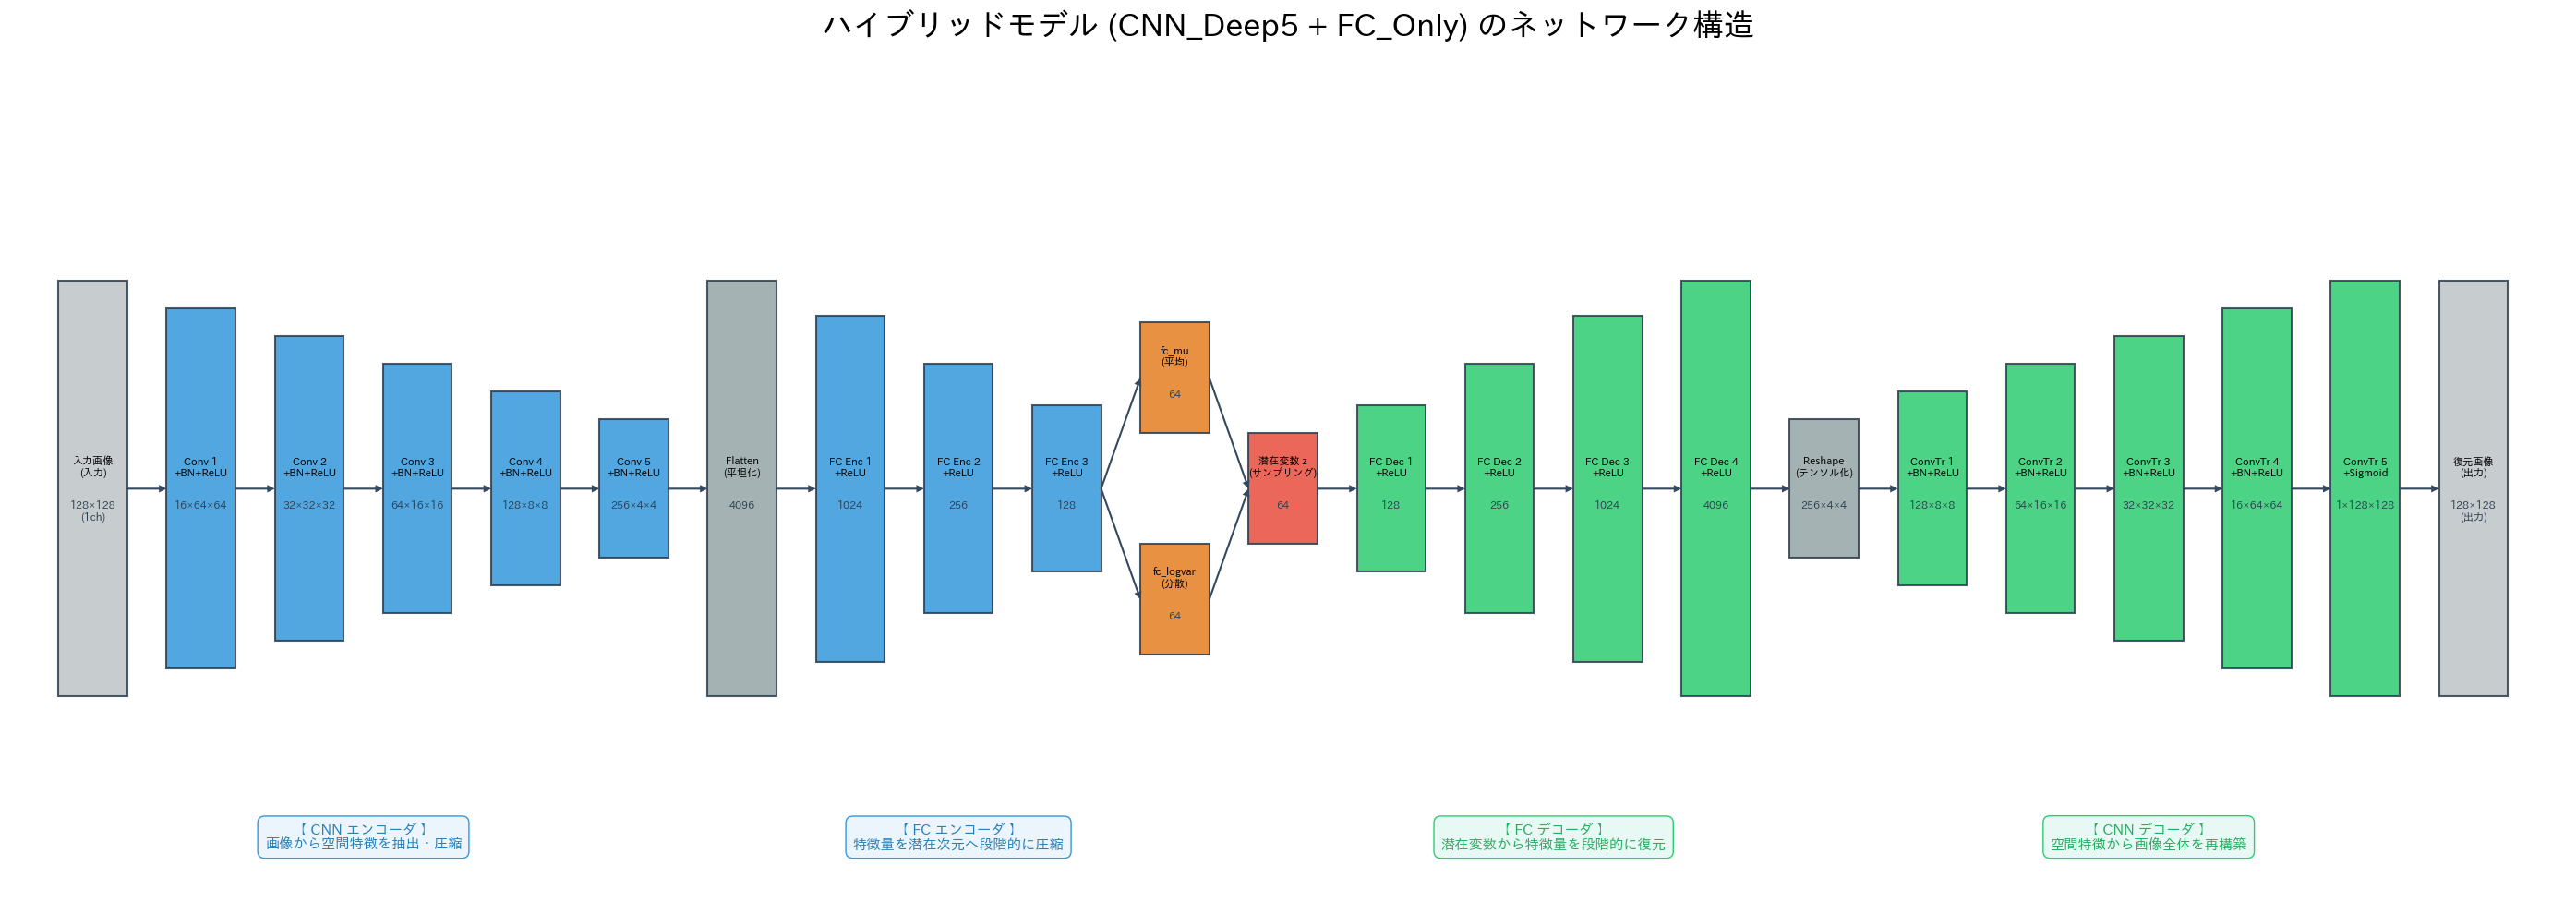

In [7]:
# ハイブリッドモデル(Hybrid_CNN5_FC)の可視化
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import japanize_matplotlib

# 文字化け対策の強制適用
japanize_matplotlib.japanize()

# =====================================================================
# 可視化用の設定
# =====================================================================
# ハイブリッドモデルは非常に長いため、横幅をさらに拡大
fig, ax = plt.subplots(figsize=(28, 10))
ax.set_xlim(0, 26)
ax.set_ylim(0, 6)
ax.axis('off')

plt.title("ハイブリッドモデル (CNN_Deep5 + FC_Only) のネットワーク構造", fontsize=24, fontweight='bold', pad=30)

# 各層の定義 [x左端, y中央, 幅, 高さ, ラベル, 次元数/サイズ, 色]
layers = [
    # 入力
    [0.5, 3.0, 0.7, 3.0, "入力画像\n(入力)", "128×128\n(1ch)", "#bdc3c7"],
    
    # 【エンコーダ前半】 CNN
    [1.6, 3.0, 0.7, 2.6, "Conv 1\n+BN+ReLU", "16×64×64", "#3498db"],
    [2.7, 3.0, 0.7, 2.2, "Conv 2\n+BN+ReLU", "32×32×32", "#3498db"],
    [3.8, 3.0, 0.7, 1.8, "Conv 3\n+BN+ReLU", "64×16×16", "#3498db"],
    [4.9, 3.0, 0.7, 1.4, "Conv 4\n+BN+ReLU", "128×8×8", "#3498db"],
    [6.0, 3.0, 0.7, 1.0, "Conv 5\n+BN+ReLU", "256×4×4", "#3498db"],
    [7.1, 3.0, 0.7, 3.0, "Flatten\n(平坦化)", "4096", "#95a5a6"],
    
    # 【エンコーダ後半】 FC
    [8.2, 3.0, 0.7, 2.5, "FC Enc 1\n+ReLU", "1024", "#3498db"],
    [9.3, 3.0, 0.7, 1.8, "FC Enc 2\n+ReLU", "256", "#3498db"],
    [10.4, 3.0, 0.7, 1.2, "FC Enc 3\n+ReLU", "128", "#3498db"],
    
    # 潜在空間 (上下に分岐)
    [11.5, 3.8, 0.7, 0.8, "fc_mu\n(平均)", "64", "#e67e22"],
    [11.5, 2.2, 0.7, 0.8, "fc_logvar\n(分散)", "64", "#e67e22"],
    [12.6, 3.0, 0.7, 0.8, "潜在変数 z\n(サンプリング)", "64", "#e74c3c"],
    
    # 【デコーダ前半】 FC
    [13.7, 3.0, 0.7, 1.2, "FC Dec 1\n+ReLU", "128", "#2ecc71"],
    [14.8, 3.0, 0.7, 1.8, "FC Dec 2\n+ReLU", "256", "#2ecc71"],
    [15.9, 3.0, 0.7, 2.5, "FC Dec 3\n+ReLU", "1024", "#2ecc71"],
    [17.0, 3.0, 0.7, 3.0, "FC Dec 4\n+ReLU", "4096", "#2ecc71"],
    [18.1, 3.0, 0.7, 1.0, "Reshape\n(テンソル化)", "256×4×4", "#95a5a6"],
    
    # 【デコーダ後半】 CNN
    [19.2, 3.0, 0.7, 1.4, "ConvTr 1\n+BN+ReLU", "128×8×8", "#2ecc71"],
    [20.3, 3.0, 0.7, 1.8, "ConvTr 2\n+BN+ReLU", "64×16×16", "#2ecc71"],
    [21.4, 3.0, 0.7, 2.2, "ConvTr 3\n+BN+ReLU", "32×32×32", "#2ecc71"],
    [22.5, 3.0, 0.7, 2.6, "ConvTr 4\n+BN+ReLU", "16×64×64", "#2ecc71"],
    [23.6, 3.0, 0.7, 3.0, "ConvTr 5\n+Sigmoid", "1×128×128", "#2ecc71"],
    
    # 出力
    [24.7, 3.0, 0.7, 3.0, "復元画像\n(出力)", "128×128\n(出力)", "#bdc3c7"]
]

for l in layers:
    x, y_mid, w, h, label, info, color = l
    y = y_mid - h/2
    
    # ブロックを描画
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='#2c3e50', facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    
    # テキスト（層の名前）
    ax.text(x + w/2, y_mid + 0.08, label, ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')
    # テキスト（次元数や画像サイズ）
    ax.text(x + w/2, y_mid - 0.08, info, ha='center', va='top', fontsize=8, color='#2c3e50', style='italic')

# ---------------------------------------------------
# 矢印（データの流れ）の描画
# ---------------------------------------------------
arrow_style = dict(facecolor='#34495e', edgecolor='none', width=1.5, headwidth=6, headlength=6, shrink=0)

def draw_arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=arrow_style)

# 直列の矢印を一括描画（分岐・合流以外）
for x_start in [0.5, 1.6, 2.7, 3.8, 4.9, 6.0, 7.1, 8.2, 9.3]:
    draw_arrow(x_start + 0.7, 3.0, x_start + 1.1, 3.0)

# FC Enc 3 -> 潜在変数への分岐
draw_arrow(10.4 + 0.7, 3.0, 11.5, 3.8)  # FC Enc 3 -> fc_mu
draw_arrow(10.4 + 0.7, 3.0, 11.5, 2.2)  # FC Enc 3 -> fc_logvar

# 潜在変数 -> z への合流
draw_arrow(11.5 + 0.7, 3.8, 12.6, 3.0)  # fc_mu -> z
draw_arrow(11.5 + 0.7, 2.2, 12.6, 3.0)  # fc_logvar -> z

# デコーダ側の直列の矢印
for x_start in [12.6, 13.7, 14.8, 15.9, 17.0, 18.1, 19.2, 20.3, 21.4, 22.5, 23.6]:
    draw_arrow(x_start + 0.7, 3.0, x_start + 1.1, 3.0)

# ---------------------------------------------------
# セクション全体の枠線とラベル
# ---------------------------------------------------
# CNN Encoder
ax.text(3.6, 0.4, "【 CNN エンコーダ 】\n画像から空間特徴を抽出・圧縮", 
        ha='center', fontsize=11, color='#2980b9', fontweight='bold', bbox=dict(facecolor='#ebf5fb', edgecolor='#3498db', boxstyle='round,pad=0.5'))
# FC Encoder
ax.text(9.65, 0.4, "【 FC エンコーダ 】\n特徴量を潜在次元へ段階的に圧縮", 
        ha='center', fontsize=11, color='#2980b9', fontweight='bold', bbox=dict(facecolor='#ebf5fb', edgecolor='#3498db', boxstyle='round,pad=0.5'))
# FC Decoder
ax.text(15.7, 0.4, "【 FC デコーダ 】\n潜在変数から特徴量を段階的に復元", 
        ha='center', fontsize=11, color='#27ae60', fontweight='bold', bbox=dict(facecolor='#e8f8f5', edgecolor='#2ecc71', boxstyle='round,pad=0.5'))
# CNN Decoder
ax.text(21.75, 0.4, "【 CNN デコーダ 】\n空間特徴から画像全体を再構築", 
        ha='center', fontsize=11, color='#27ae60', fontweight='bold', bbox=dict(facecolor='#e8f8f5', edgecolor='#2ecc71', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()